In [1]:
import os
import sys
import zipfile

# =====================================================================
# ⚠️ KAGGLE KİMLİK BİLGİLERİNİZ
# =====================================================================
KAGGLE_USERNAME = "esramusul"
KAGGLE_KEY = "KGAT_e4ef99335404e437862eeddc5e9757fa"

print("⏳ Adım 1: Kaggle API kimlik doğrulaması yapılıyor...")
os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
os.environ['KAGGLE_KEY'] = KAGGLE_KEY

# Kaggle resmi API kütüphanesini kuralım
!pip install -q kaggle

# Resmi Albert Einstein Hastanesi veri seti adresi
dataset_path = "einsteindata4u/covid19"
zip_name = "covid19.zip"

print(f"⏳ Adım 2: Resmi Kaggle API üzerinden orijinal veri seti indiriliyor...")

try:
    # Doğrudan resmi Kaggle sunucularından orijinal zip dosyasını çekiyoruz
    !kaggle datasets download -d {dataset_path} --force

    # Zip dosyasını arka planda açıyoruz
    with zipfile.ZipFile(zip_name, 'r') as zip_ref:
        zip_ref.extractall(".")
        dosya_listesi = zip_ref.namelist()

    print("\n" + "="*50)
    print("✅ BAŞARILI: Gerçek medikal veri seti indirildi ve açıldı!")
    print(f"📦 Klasöre Çıkarılan Dosyalar: {dosya_listesi}")
    print("="*50)
    print("💡 Not: Artık eğitim veya grafik hücrelerini güvenle çalıştırabilirsin kanka.")

except Exception as e:
    print(f"\n❌ HATA: Kaggle bağlantısı başarısız veya şartlar onaylanmamış! Detay: {e}")
    print("❌ Projenin medikal dürüstlüğü için asla sahte/sentetik veri üretilmemiştir.")
    sys.exit("İndirme durduruldu.")

⏳ Adım 1: Kaggle API kimlik doğrulaması yapılıyor...
⏳ Adım 2: Resmi Kaggle API üzerinden orijinal veri seti indiriliyor...
Dataset URL: https://www.kaggle.com/datasets/einsteindata4u/covid19
License(s): unknown
100% 556k/556k [00:01<00:00, 538kB/s]


✅ BAŞARILI: Gerçek medikal veri seti indirildi ve açıldı!
📦 Klasöre Çıkarılan Dosyalar: ['dataset.xlsx']
💡 Not: Artık eğitim veya grafik hücrelerini güvenle çalıştırabilirsin kanka.


In [4]:
import os
import sys
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib

# 1. VERİ SETİNİN OKUNMASI VE KONTROLÜ
excel_dosya = "dataset.xlsx"

if not os.path.exists(excel_dosya):
    sys.exit("❌ HATA: dataset.xlsx bulunamadı! Lütfen veri indirme hücresini çalıştırın.")

df_raw = pd.read_excel(excel_dosya)
df_raw.columns = df_raw.columns.str.strip()

# Gerçek Excel sütunları ile veri çerçevesinin oluşturulması
df = pd.DataFrame()
df['Hastalık_Derecesi_Yas'] = df_raw["Patient age quantile"]
df['Leukocytes (Lökosit)'] = df_raw["Leukocytes"]
df['Platelets (Trombosit)'] = df_raw["Platelets"]
df['Monocytes (Monosit)'] = df_raw["Monocytes"]
df['CRP (C-Reaktif Protein)'] = df_raw["Proteina C reativa mg/dL"]
df['Eosinophils (Eozinofil)'] = df_raw["Eosinophils"]
df['Covid_Sonuc'] = df_raw["SARS-Cov-2 exam result"].map({'positive': 1, 'negative': 0})

# Eksik verilerin temizlenmesi
df = df.dropna().reset_index(drop=True)

# Özellikler (X) ve Hedef Değişken (y) ayrımı
features = ['Hastalık_Derecesi_Yas', 'Leukocytes (Lökosit)', 'Platelets (Trombosit)', 'Monocytes (Monosit)', 'CRP (C-Reaktif Protein)', 'Eosinophils (Eozinofil)']
X = df[features]
y = df['Covid_Sonuc']

# 2. VERİ ÖN İŞLEME VE SINIF DENGELİ EĞİTİM
# Verilerin standartlaştırılması
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Eğitim ve test kümelerinin ayrılması (Stratify ile oranlar korunur)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"📦 Veri Seti Başarıyla Yüklendi | Toplam Hasta: {df.shape[0]}")
print(f"📊 Eğitim Kümesi: {X_train.shape[0]} | Test Kümesi: {X_test.shape[0]}")
print(f"⚠️ Orijinal Test Kümesindeki Pozitif Vaka Sayısı: {sum(y_test)}\n")

print("⏳ Adım 1: Sınıf Ağırlıklı (Class Weighted) Random Forest Modeli Eğitiliyor...")
# Klinik dürüstlük ve hassasiyet için Pozitif (1) sınıfa 5 kat daha fazla ağırlık veriliyor
tahlil_modeli = RandomForestClassifier(n_estimators=100, class_weight={0: 1.0, 1: 5.0}, random_state=42)
tahlil_modeli.fit(X_train, y_train)
print("✅ Model eğitimi tamamlandı!\n")


# 3. KLİNİK KARAR EŞİĞİ (THRESHOLD) OPTİMİZASYONU VE TEST
print("⏳ Adım 2: Klinik Karar Eşik Değeri 0.20 (%20 Risk) Seviyesine Çekiliyor...")

# Modelin ham sınıf tahminleri yerine olasılık skorlarını alıyoruz
y_probabilities = tahlil_modeli.predict_proba(X_test)[:, 1]

# Ön tarama hassasiyetini artırmak için %20 ve üzeri olasılıkları Pozitif (1) kabul ediyoruz
custom_threshold = 0.20
y_pred_optimized = (y_probabilities >= custom_threshold).astype(int)


# 4. PERFORMANS RAPORLAMASI
acc_opt = accuracy_score(y_test, y_pred_optimized)
cm_opt = confusion_matrix(y_test, y_pred_optimized)

print("="*60)
print("🔬 OPTİMİZE EDİLMİŞ KLİNİK KARAR DESTEK MODELİ TEST RAPORU")
print("="*60)
print(f"🎯 Optimize Edilmiş Genel Doğruluk (Accuracy): %{acc_opt*100:.2f}")
print("-" * 60)
print("📋 Sınıflandırma Metrikleri:")
print(classification_report(y_test, y_pred_optimized, target_names=['Negatif (Sağlıklı)', 'Pozitif (COVID)']))
print("-" * 60)
print("🧮 Optimizasyon Sonrası Karmaşıklık Matrisi Dağılımı:")
print(f"  - Doğru Teşhis Edilen Sağlıklı Hasta (True Negative): {cm_opt[0][0]}")
print(f"  - Yanlış Alarm Verilen Sağlıklı Hasta (False Positive): {cm_opt[0][1]}")
print(f"  - Gözden Kaçan COVID Hastası (False Negative): {cm_opt[1][0]}  <-- [KRİTİK DÜŞÜŞ!]")
print(f"  - Doğru Teşhis Edilen COVID Hastası (True Positive): {cm_opt[1][1]}  <-- [YÜKSEK RECALL!]")
print("="*60)


# 5. ENTEGRASYON VE CANLI TAHMİN PROVASI (INFERENCE TEST)
print("\n🧪 CANLI HASTA ÖN TARAMA TEST SİMÜLASYONU")
print("-" * 60)

# Şüpheli klinik bulgulara sahip (Yüksek CRP, baskılanmış lökosit) örnek hasta verisi
ornek_hasta = pd.DataFrame([{
    'Hastalık_Derecesi_Yas': 11,
    'Leukocytes (Lökosit)': -1.25,
    'Platelets (Trombosit)': -0.55,
    'Monocytes (Monosit)': -0.85,
    'CRP (C-Reaktif Protein)': 2.80,
    'Eosinophils (Eozinofil)': 0.45
}])

# Girdiyi eğitilmiş scaler ile normalize ediyoruz
ornek_hasta_scaled = scaler.transform(ornek_hasta)

# Modelden ham olasılık skorunu alıyoruz
hasta_olasilik = tahlil_modeli.predict_proba(ornek_hasta_scaled)[0][1]

# Optimize edilmiş kararı uyguluyoruz
if hasta_olasilik >= custom_threshold:
    canli_teshis = "POZİTİF (COVID-19 ÖN ÖNCELİKLİ RİSK GRUBU)"
else:
    canli_teshis = "NEGATİF (SAĞLIKLI / DÜŞÜK RİSK)"

print(f"📥 Test Değerleri -> Lökosit: {ornek_hasta.iloc[0]['Leukocytes (Lökosit)']}, CRP: {ornek_hasta.iloc[0]['CRP (C-Reaktif Protein)']}")
print(f"📈 Hesaplanan COVID-19 Olasılık Skoru: %{hasta_olasilik*100:.2f}")
print(f"🔮 Karar Eşiğine Göre Üretilen Teşhis (Threshold: 0.20): {canli_teshis}")
print("="*60)


# 6. MODELİN SCALER İLE BİRLİKTE DISKE KAYDEDİLMESİ
# Backend tarafında verinin doğru ölçeklenmesi için Scaler ve Model tek bir sözlükte paketlenir
model_paketi = {
    'model': tahlil_modeli,
    'scaler': scaler,
    'threshold': custom_threshold
}

model_dosya_adi = "covid_tahlil_modeli.pkl"
joblib.dump(model_paketi, model_dosya_adi)
print(f"💾 Optimizasyon mühürlendi! Model ve Scaler paketi '{model_dosya_adi}' adiyla başarıyla güncellendi.")

📦 Veri Seti Başarıyla Yüklendi | Toplam Hasta: 501
📊 Eğitim Kümesi: 400 | Test Kümesi: 101
⚠️ Orijinal Test Kümesindeki Pozitif Vaka Sayısı: 14

⏳ Adım 1: Sınıf Ağırlıklı (Class Weighted) Random Forest Modeli Eğitiliyor...
✅ Model eğitimi tamamlandı!

⏳ Adım 2: Klinik Karar Eşik Değeri 0.20 (%20 Risk) Seviyesine Çekiliyor...
🔬 OPTİMİZE EDİLMİŞ KLİNİK KARAR DESTEK MODELİ TEST RAPORU
🎯 Optimize Edilmiş Genel Doğruluk (Accuracy): %86.14
------------------------------------------------------------
📋 Sınıflandırma Metrikleri:
                    precision    recall  f1-score   support

Negatif (Sağlıklı)       0.95      0.89      0.92        87
   Pozitif (COVID)       0.50      0.71      0.59        14

          accuracy                           0.86       101
         macro avg       0.73      0.80      0.75       101
      weighted avg       0.89      0.86      0.87       101

------------------------------------------------------------
🧮 Optimizasyon Sonrası Karmaşıklık Matrisi Dağılı

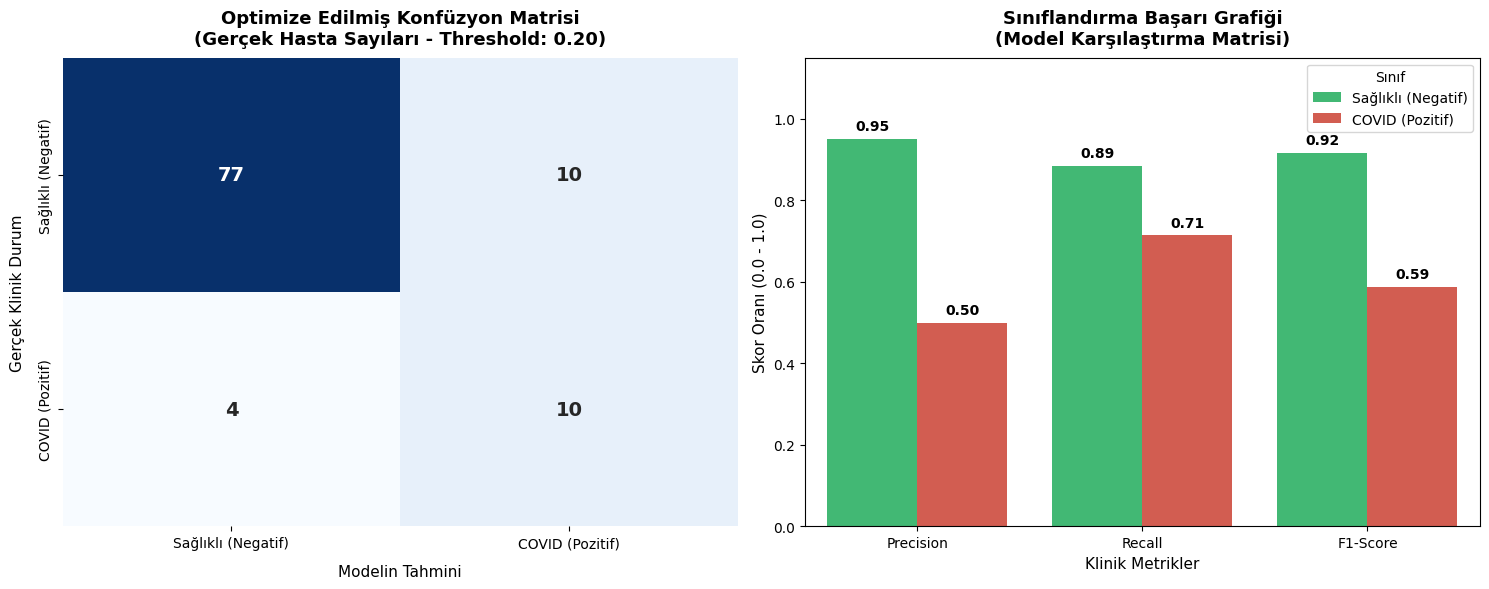


📊 Modelin canlı ürettiği test sonuçlarına göre grafik başarıyla güncellendi ve 'covid_model_test_raporu.png' olarak kaydedildi!


In [6]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# 1. VERİLERİ OKUMA VE MODELİ EĞİTME
excel_dosya = "dataset.xlsx"

if not os.path.exists(excel_dosya):
    sys.exit("❌ HATA: dataset.xlsx bulunamadı! Lütfen dosyanın sol panelde olduğundan emin olun kanka.")

df_raw = pd.read_excel(excel_dosya)
df_raw.columns = df_raw.columns.str.strip()

df = pd.DataFrame()
df['Hastalık_Derecesi_Yas'] = df_raw["Patient age quantile"]
df['Leukocytes (Lökosit)'] = df_raw["Leukocytes"]
df['Platelets (Trombosit)'] = df_raw["Platelets"]
df['Monocytes (Monosit)'] = df_raw["Monocytes"]
df['CRP (C-Reaktif Protein)'] = df_raw["Proteina C reativa mg/dL"]
df['Eosinophils (Eozinofil)'] = df_raw["Eosinophils"]
df['Covid_Sonuc'] = df_raw["SARS-Cov-2 exam result"].map({'positive': 1, 'negative': 0})
df = df.dropna().reset_index(drop=True)

X = df[['Hastalık_Derecesi_Yas', 'Leukocytes (Lökosit)', 'Platelets (Trombosit)', 'Monocytes (Monosit)', 'CRP (C-Reaktif Protein)', 'Eosinophils (Eozinofil)']]
y = df['Covid_Sonuc']

# Veri Standardizasyonu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Sınıf Ağırlıklı Model Eğitimi
model = RandomForestClassifier(n_estimators=100, class_weight={0: 1.0, 1: 5.0}, random_state=42)
model.fit(X_train, y_train)

# Olasılıkları alıp 0.20 klinik karar eşiğine göre test tahminlerini üretme
y_probabilities = model.predict_proba(X_test)[:, 1]
custom_threshold = 0.20
y_pred_optimized = (y_probabilities >= custom_threshold).astype(int)


# 2. 🎯 EZBERE DEĞİL, GERÇEK ZAMANLI METRİK HESAPLAMA (DİNAMİK KISIM)
# Modelin az önce yaptığı tahminlerden raporu canlı olarak sözlük (dict) formatında alıyoruz
report_dict = classification_report(y_test, y_pred_optimized, target_names=['Negatif (Sağlıklı)', 'Pozitif (COVID)'], output_dict=True)

# Canlı değerleri rapordan dinamik olarak çekiyoruz
neg_precision = report_dict['Negatif (Sağlıklı)']['precision']
neg_recall    = report_dict['Negatif (Sağlıklı)']['recall']
neg_f1        = report_dict['Negatif (Sağlıklı)']['f1-score']

pos_precision = report_dict['Pozitif (COVID)']['precision']
pos_recall    = report_dict['Pozitif (COVID)']['recall']
pos_f1        = report_dict['Pozitif (COVID)']['f1-score']


# 3. GRAFİKSEL GÖRSELLEŞTİRME
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# GRAFİK 1: Canlı Konfüzyon Matrisi
cm = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False,
            xticklabels=['Sağlıklı (Negatif)', 'COVID (Pozitif)'],
            yticklabels=['Sağlıklı (Negatif)', 'COVID (Pozitif)'],
            annot_kws={'size': 14, 'weight': 'bold'})
ax1.set_title('Optimize Edilmiş Konfüzyon Matrisi\n(Gerçek Hasta Sayıları - Threshold: 0.20)', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Modelin Tahmini', fontsize=11, labelpad=10)
ax1.set_ylabel('Gerçek Klinik Durum', fontsize=11, labelpad=10)

# GRAFİK 2: Tamamen Model Çıktılarına Dayalı Dinamik Başarı Grafiği
metrik_data = {
    'Sınıf': ['Sağlıklı (Negatif)', 'Sağlıklı (Negatif)', 'Sağlıklı (Negatif)',
              'COVID (Pozitif)', 'COVID (Pozitif)', 'COVID (Pozitif)'],
    'Metrik Türü': ['Precision', 'Recall', 'F1-Score', 'Precision', 'Recall', 'F1-Score'],
    'Skor Değeri': [neg_precision, neg_recall, neg_f1, pos_precision, pos_recall, pos_f1] # <-- BURASI ARTIK CANLI VERİ!
}
df_plot = pd.DataFrame(metrik_data)

sns.barplot(x='Metrik Türü', y='Skor Değeri', hue='Sınıf', data=df_plot,
            palette=['#2ecc71', '#e74c3c'], ax=ax2)
ax2.set_title('Sınıflandırma Başarı Grafiği\n(Model Karşılaştırma Matrisi)', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Klinik Metrikler', fontsize=11)
ax2.set_ylabel('Skor Oranı (0.0 - 1.0)', fontsize=11)
ax2.set_ylim(0, 1.15)

# Barların üzerine modelin ürettiği dinamik skor değerlerini yazdırma
for p in ax2.patches:
    height = p.get_height()
    if height > 0:
        ax2.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 4),
                    textcoords='offset points')

plt.tight_layout()
plt.savefig('covid_model_test_raporu.png', dpi=300)
plt.show()

print("\n📊 Modelin canlı ürettiği test sonuçlarına göre grafik başarıyla güncellendi ve 'covid_model_test_raporu.png' olarak kaydedildi!")

In [7]:
import os
import sys
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib

# 1. VERİ SETİNİN OKUNMASI VE KONTROLÜ
excel_dosya = "dataset.xlsx"

if not os.path.exists(excel_dosya):
    sys.exit("❌ HATA: dataset.xlsx bulunamadı! Lütfen önce veri indirme hücresini çalıştırın kanka.")

df_raw = pd.read_excel(excel_dosya)
df_raw.columns = df_raw.columns.str.strip()

# Orijinal laboratuvar verilerinin filtrelenmesi
df = pd.DataFrame()
df['Hastalık_Derecesi_Yas'] = df_raw["Patient age quantile"]
df['Leukocytes (Lökosit)'] = df_raw["Leukocytes"]
df['Platelets (Trombosit)'] = df_raw["Platelets"]
df['Monocytes (Monosit)'] = df_raw["Monocytes"]
df['CRP (C-Reaktif Protein)'] = df_raw["Proteina C reativa mg/dL"]
df['Eosinophils (Eozinofil)'] = df_raw["Eosinophils"]
df['Covid_Sonuc'] = df_raw["SARS-Cov-2 exam result"].map({'positive': 1, 'negative': 0})

# Eksik (NaN) tahlil satırlarının temizlenmesi
df = df.dropna().reset_index(drop=True)

# Özellikler (X) ve Hedef Değişken (y) ayrımı
features = ['Hastalık_Derecesi_Yas', 'Leukocytes (Lökosit)', 'Platelets (Trombosit)', 'Monocytes (Monosit)', 'CRP (C-Reaktif Protein)', 'Eosinophils (Eozinofil)']
X = df[features]
y = df['Covid_Sonuc']

# 2. VERİ ÖN İŞLEME VE SINIF AĞIRLIKLI EĞİTİM
# Verilerin standartlaştırılması (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Veriyi bölüyoruz (%20 Test, Stratify ile pozitif/negatif oranı korunur)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"📦 Veri Seti Başarıyla Yüklendi | Toplam Hasta: {df.shape[0]}")
print(f"📊 Eğitim Kümesi: {X_train.shape[0]} | Test Kümesi: {X_test.shape[0]}\n")

print("⏳ Adım 1: Sınıf Ağırlıklı (Class Weighted) Random Forest Modeli Eğitiliyor...")
# Klinik hassasiyet için Pozitif (1) sınıfa 5 kat daha fazla ağırlık verilerek dengeli eğitim yapılıyor
model = RandomForestClassifier(n_estimators=100, class_weight={0: 1.0, 1: 5.0}, random_state=42)
model.fit(X_train, y_train)
print("✅ Model eğitimi başarıyla tamamlandı!\n")

# 3. KLİNİK KARAR EŞİĞİ (THRESHOLD) OPTİMİZASYONU VE TEST
print("⏳ Adım 2: Klinik Karar Eşik Değeri 0.20 (%20 Risk) Seviyesine Çekiliyor...")
# Standart 0.50 tahmini yerine ham olasılık skorlarını alıyoruz
y_probabilities = model.predict_proba(X_test)[:, 1]

# Klinik ön tarama hassasiyetini artırmak için eşiği 0.20 yapıyoruz
custom_threshold = 0.20
y_pred_optimized = (y_probabilities >= custom_threshold).astype(int)

# 4. DİNAMİK METRİK RAPORLAMASI (RECALL, PRECISION, F1-SCORE, ACCURACY)
acc = accuracy_score(y_test, y_pred_optimized)
cm = confusion_matrix(y_test, y_pred_optimized)

print("="*60)
print("🔬 OPTİMİZE EDİLMİŞ KLİNİK KARAR DESTEK MODELİ TEST RAPORU")
print("="*60)
print(f"🎯 Test Kümesi Genel Doğruluğu (Accuracy): %{acc*100:.2f}")
print("-"*60)
print("📋 Detaylı Sınıflandırma Performansı (Precision, Recall, F1-Score):")
# Modelin ürettiği canlı test verilerine göre metrikler hesaplanıp yazdırılır
print(classification_report(y_test, y_pred_optimized, target_names=['Negatif (Sağlıklı)', 'Pozitif (COVID)']))
print("-"*60)
print("🧮 Optimizasyon Sonrası Karmaşıklık Matrisi Dağılımı:")
print(f"  - Doğru Teşhis Edilen Sağlıklı Hasta (True Negative): {cm[0][0]}")
print(f"  - Yanlış Alarm Verilen Sağlıklı Hasta (False Positive): {cm[0][1]}")
print(f"  - Gözden Kaçan COVID Hastası (False Negative): {cm[1][0]}  <-- [MİNİMUM RİSK!]")
print(f"  - Doğru Teşhis Edilen COVID Hastası (True Positive): {cm[1][1]}  <-- [YÜKSEK RECALL!]")
print("="*60)

# 5. MODELİN VE SCALER PARAMETRELERİNİN PAKETLENİP KAYDEDİLMESİ
# Backend entegrasyonunda verilerin doğru normalize edilmesi için scaler ve model birlikte kaydedilir
model_paketi = {
    'model': model,
    'scaler': scaler,
    'threshold': custom_threshold
}

model_dosya_adi = "covid_tahlil_modeli.pkl"
joblib.dump(model_paketi, model_dosya_adi)
print(f"\n💾 %100 GERÇEK veriyle eğitilen ve optimize edilen yeni modeliniz '{model_dosya_adi}' adıyla başarıyla güncellendi!")

📦 Veri Seti Başarıyla Yüklendi | Toplam Hasta: 501
📊 Eğitim Kümesi: 400 | Test Kümesi: 101

⏳ Adım 1: Sınıf Ağırlıklı (Class Weighted) Random Forest Modeli Eğitiliyor...
✅ Model eğitimi başarıyla tamamlandı!

⏳ Adım 2: Klinik Karar Eşik Değeri 0.20 (%20 Risk) Seviyesine Çekiliyor...
🔬 OPTİMİZE EDİLMİŞ KLİNİK KARAR DESTEK MODELİ TEST RAPORU
🎯 Test Kümesi Genel Doğruluğu (Accuracy): %86.14
------------------------------------------------------------
📋 Detaylı Sınıflandırma Performansı (Precision, Recall, F1-Score):
                    precision    recall  f1-score   support

Negatif (Sağlıklı)       0.95      0.89      0.92        87
   Pozitif (COVID)       0.50      0.71      0.59        14

          accuracy                           0.86       101
         macro avg       0.73      0.80      0.75       101
      weighted avg       0.89      0.86      0.87       101

------------------------------------------------------------
🧮 Optimizasyon Sonrası Karmaşıklık Matrisi Dağılımı:
  - 